# Análisis de costes de seguros médicos — Curso 0 Python (Máster en Ciencias Actuariales, UC3M)

Este notebook es donde se desarrolla y documenta el análisis. **No define funciones**: importa las de
`scripts/funciones.py` (que son genéricas y reutilizables) y las aplica a nuestros datos.

Estructura del notebook:
1. Parámetros e imports
2. Descarga de los datos desde GitHub y carga en la base de datos
3. Exploración inicial y calidad de los datos
4. Histogramas
5. Coste médico según las características del asegurado (consultas SQL)
6. Asociación entre ser fumador y no tener hijos
7. Guardar los gráficos en un PDF
8. Conclusiones

## 1. Parámetros e imports

Todo lo que depende de *este* proyecto concreto (la URL de los datos, las rutas, el nombre de la tabla)
se define aquí arriba como parámetros. Las funciones reciben estos valores como argumentos, así que para
usarlas con otra base de datos solo habría que cambiar esta celda.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Carpeta raíz del proyecto: funciona tanto si Jupyter arranca en notebooks/ como en la raíz
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "scripts").is_dir() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))  # para poder hacer "from scripts.funciones import ..."

from scripts.funciones import (
    descargar_csv, cargar_csv_en_db, leer_tabla, consultar, media_por_grupo,
    histograma, boxplot_por_grupo, guardar_figuras_pdf,
    tabla_contingencia, test_asociacion, resumen_asociacion,
)

# ---- Parámetros del análisis ----
URL_DATOS = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
DATA_DIR = PROJECT_ROOT / "data"
RUTA_CSV = DATA_DIR / "seguros.csv"
RUTA_DB = DATA_DIR / "proyecto.db"
TABLA = "seguros"
RUTA_PDF = DATA_DIR / "graficos.pdf"

## 2. Descarga de los datos y carga en la base de datos

Usamos el dataset público *Medical Cost Personal Datasets* (1.338 asegurados), alojado en GitHub.

- `descargar_csv(url, ruta_destino)` lo descarga y guarda una **copia exacta** en `data/` (los mismos bytes que el
  original, así que si los datos no han cambiado, git no detecta ningún cambio en el fichero).
- `cargar_csv_en_db(ruta_csv, ruta_db, nombre_tabla)` lo guarda como tabla en la base de datos SQLite.

Si no hay conexión a internet, se usa la copia local que ya está en el repositorio.

In [2]:
try:
    descargar_csv(URL_DATOS, RUTA_CSV)
    print(f"Datos descargados de GitHub y guardados en {RUTA_CSV.relative_to(PROJECT_ROOT)}")
except Exception as error:
    print(f"No se pudo descargar ({type(error).__name__}: {error})")
    print(f"Se usa la copia local {RUTA_CSV.relative_to(PROJECT_ROOT)}")

n_filas = cargar_csv_en_db(RUTA_CSV, RUTA_DB, TABLA)
print(f"Tabla '{TABLA}' cargada en la base de datos con {n_filas} filas")

Datos descargados de GitHub y guardados en data\seguros.csv
Tabla 'seguros' cargada en la base de datos con 1338 filas


## 3. Exploración inicial y calidad de los datos

Leemos la tabla desde la base de datos con `leer_tabla()` y echamos un primer vistazo.

| Columna    | Descripción |
|------------|-------------|
| `age`      | Edad del asegurado |
| `sex`      | Sexo (female / male) |
| `bmi`      | Índice de masa corporal |
| `children` | Número de hijos a cargo |
| `smoker`   | Si fuma (yes / no) |
| `region`   | Región de residencia en EE. UU. |
| `charges`  | **Coste médico facturado al seguro** en un año (USD). No es la prima que paga el asegurado, sino lo que le cuesta a la aseguradora. |

In [3]:
df = leer_tabla(RUTA_DB, TABLA)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


Antes de analizar, comprobamos si hay **valores que faltan** o **filas repetidas**:

In [5]:
print(f"Valores que faltan: {df.isna().sum().sum()}")
print(f"Filas duplicadas:   {df.duplicated().sum()}")
df[df.duplicated(keep=False)]

Valores que faltan: 0
Filas duplicadas:   1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


No falta ningún valor. Hay **una fila repetida**: dos asegurados con exactamente las mismas características y el mismo coste.
Como el dataset no tiene un identificador de cliente, no podemos saber si es un error de carga o dos personas distintas.
La **mantenemos**: es 1 fila de 1.338 y no cambia ningún resultado, pero lo dejamos anotado.

## 4. Histogramas

`histograma(datos, ancho_banda, titulo)` recibe **cualquier columna numérica** y devuelve la figura sin
mostrarla ni guardarla. Así podemos reutilizar la misma función para varias variables. Guardamos todas las
figuras en una lista para juntarlas después en un PDF.

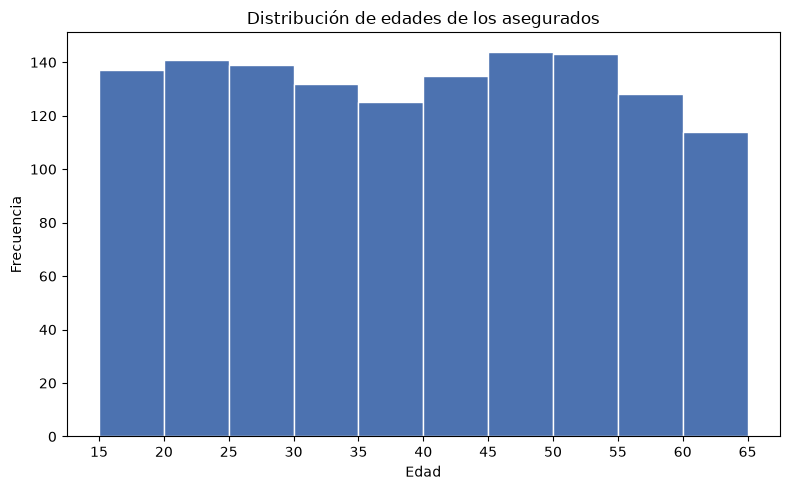

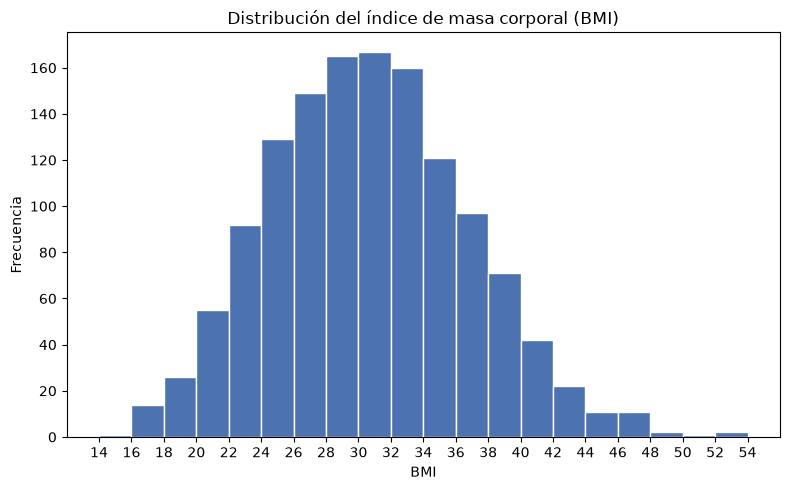

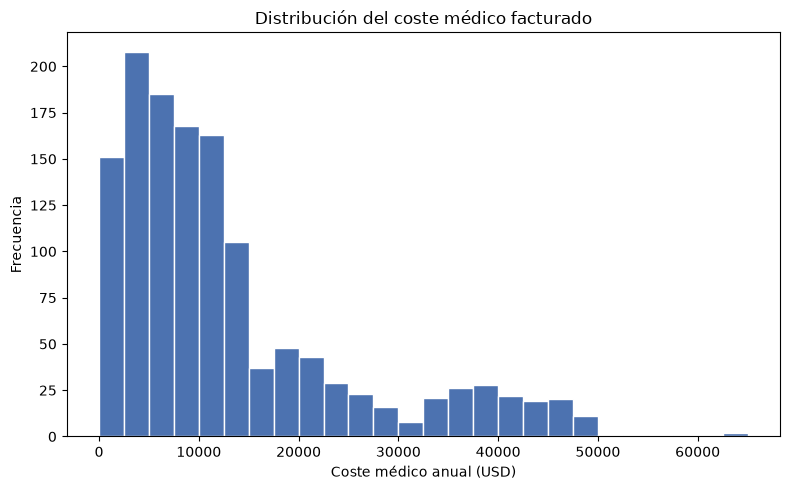

In [6]:
figuras = []

fig, ax = histograma(df["age"], ancho_banda=5, titulo="Distribución de edades de los asegurados", etiqueta_x="Edad")
figuras.append(fig)

fig, ax = histograma(df["bmi"], ancho_banda=2, titulo="Distribución del índice de masa corporal (BMI)", etiqueta_x="BMI")
figuras.append(fig)

fig, ax = histograma(df["charges"], ancho_banda=2500, titulo="Distribución del coste médico facturado",
                     etiqueta_x="Coste médico anual (USD)")
figuras.append(fig)

plt.show()

Las edades se reparten de forma bastante uniforme entre 18 y 64 años, el BMI tiene forma de campana y el coste
es muy **asimétrico a la derecha**: la mayoría de asegurados cuesta poco y unos pocos cuestan mucho. Esa cola es
justo lo que interesa a un actuario.

## 5. Coste médico según las características del asegurado (consultas SQL)

Ahora usamos la base de datos con **consultas SQL**. `media_por_grupo()` ejecuta un `GROUP BY` que calcula, para
cada categoría, cuántos asegurados hay y su coste medio, mínimo y máximo. Empezamos por el tabaco:

In [7]:
media_por_grupo(RUTA_DB, TABLA, "charges", "smoker").round(2)

,n,media,minimo,maximo
grupo,,,,
yes,274,32050.23,12829.46,63770.43
no,1064,8434.27,1121.87,36910.61


Con `consultar()` se puede lanzar cualquier consulta. Por ejemplo, la misma comparación pero separando por sexo:

In [8]:
consultar(RUTA_DB, '''
    SELECT sex, smoker, COUNT(*) AS n, ROUND(AVG(charges), 2) AS coste_medio
    FROM seguros
    GROUP BY sex, smoker
    ORDER BY sex, smoker
''')

,sex,smoker,n,coste_medio
0,female,no,547,8762.30
1,female,yes,115,30679.00
2,male,no,517,8087.20
3,male,yes,159,33042.01


Para ver qué característica **separa más** el coste, repetimos el `GROUP BY` con cada variable categórica y
calculamos el cociente entre el grupo más caro y el más barato:

In [9]:
comparacion = {}
for variable in ["smoker", "sex", "region", "children"]:
    medias = media_por_grupo(RUTA_DB, TABLA, "charges", variable)["media"]
    comparacion[variable] = {
        "grupo_mas_caro": str(medias.idxmax()),
        "grupo_mas_barato": str(medias.idxmin()),
        "cociente_medias": round(medias.max() / medias.min(), 2),
    }

pd.DataFrame(comparacion).T.sort_values("cociente_medias", ascending=False)

,grupo_mas_caro,grupo_mas_barato,cociente_medias
smoker,yes,no,3.8
children,3,5,1.75
region,southeast,southwest,1.19
sex,male,female,1.11


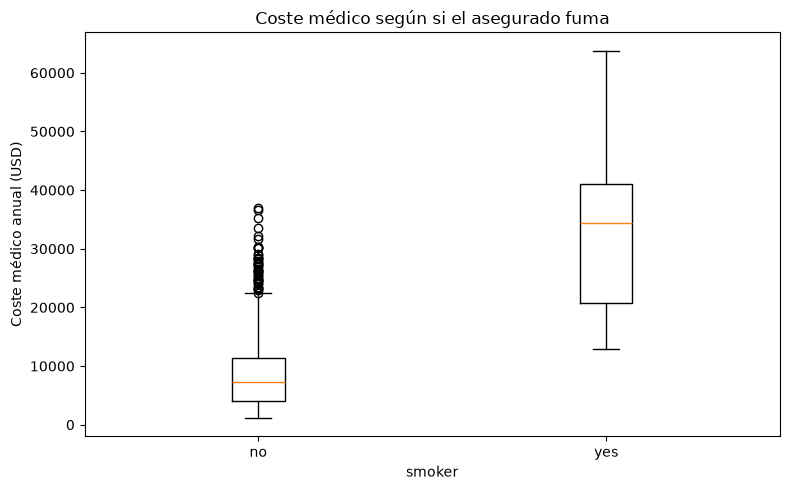

In [10]:
fig, ax = boxplot_por_grupo(df, "charges", "smoker", titulo="Coste médico según si el asegurado fuma",
                            etiqueta_y="Coste médico anual (USD)")
figuras.append(fig)
plt.show()

Los fumadores cuestan de media **unas 3,8 veces más** que los no fumadores, y en el diagrama de cajas casi no se
solapan. Entre las variables categóricas del dataset, ser fumador es con diferencia la que más separa el coste
(el resto no llega ni a duplicarlo). Es una comparación de medias, sin controlar por otras variables como la edad
o el BMI; para eso haría falta un modelo de regresión.

## 6. Asociación entre ser fumador y no tener hijos

**Pregunta:** ¿las personas sin hijos fuman más (o menos) que las que tienen hijos?

### 6.1 Preparar las variables

Las dos variables que queremos relacionar son **categóricas**, no numéricas, así que las convertimos a binario (1 = sí, 0 = no):
- `fumador` = 1 si `smoker == "yes"`
- `sin_hijos` = 1 si `children == 0`

Esta transformación es propia de *este* análisis, por eso se hace aquí en el notebook y no en el script.

In [11]:
df["fumador"] = (df["smoker"] == "yes").astype(int)
df["sin_hijos"] = (df["children"] == 0).astype(int)
df[["smoker", "children", "fumador", "sin_hijos"]].head()

,smoker,children,fumador,sin_hijos
0,yes,0,1,1
1,no,1,0,0
2,no,3,0,0
3,no,0,0,1
4,no,0,0,1


### 6.2 ¿Por qué una tabla de contingencia (`pd.crosstab`)?

Con variables categóricas no tiene sentido hacer cuentas con los valores (no hay una "media de fumar"). Lo que
sí podemos estudiar es **cuántas personas caen en cada combinación de categorías**. Eso es exactamente una
tabla de contingencia, y `pd.crosstab` la construye contando las filas del DataFrame:

|                 | con hijos (0) | sin hijos (1) |
|-----------------|---------------|---------------|
| no fumador (0)  | a             | b             |
| fumador (1)     | c             | d             |

La necesitamos porque:
1. **El test chi-cuadrado trabaja sobre frecuencias, no sobre las filas originales.** `chi2_contingency` compara
   los recuentos observados en cada casilla con los que esperaríamos si las dos variables fueran independientes.
   Si la diferencia es grande, rechazamos la independencia.
2. **El coeficiente phi se calcula a partir de las cuatro casillas:**
   $\phi = \dfrac{ad - bc}{\sqrt{(a+b)(c+d)(a+c)(b+d)}}$.
   Phi es la correlación de Pearson aplicada a dos variables 0/1 y va de −1 a 1: cerca de 0 indica que no hay relación.
3. Además, permite **ver los datos**: antes de calcular nada ya se aprecia si las proporciones son parecidas o no.

Primero miramos la tabla con `tabla_contingencia()`:

In [12]:
tabla = tabla_contingencia(df, "fumador", "sin_hijos")
tabla

sin_hijos,0,1
fumador,,
0,605,459
1,159,115


Para comparar mejor, vemos la proporción de fumadores dentro de cada grupo (cada columna suma 1):

In [13]:
(tabla / tabla.sum()).round(3)

sin_hijos,0,1
fumador,,
0,0.792,0.8
1,0.208,0.2


### 6.3 Test chi-cuadrado, phi y V de Cramér

`test_asociacion(df, var1, var2)` construye la tabla de contingencia, aplica el test chi-cuadrado
(H0: las variables son independientes) y mide la fuerza de la relación con phi (solo tablas 2×2, con signo) y con
la V de Cramér (cualquier tabla, de 0 a 1). Lo aplicamos a todos los asegurados y, filtrando el DataFrame en el
notebook, por separado a mujeres y hombres.

Dos detalles técnicos:
- **No aplicamos la corrección de Yates.** Solo importa con muestras pequeñas, y sin ella se cumple
  $\chi^2 = n\,\phi^2$, así que el test y phi cuentan exactamente la misma historia (lo comprobamos abajo).
- `esperada_min` es la menor frecuencia esperada de la tabla: el test chi-cuadrado es fiable cuando todas son ≥ 5.

In [14]:
grupos = {
    "Todos": df,
    "Mujeres": df[df["sex"] == "female"],
    "Hombres": df[df["sex"] == "male"],
}

resultados = {nombre: test_asociacion(datos, "fumador", "sin_hijos") for nombre, datos in grupos.items()}

resumen = pd.DataFrame({nombre: resumen_asociacion(r) for nombre, r in resultados.items()}).T
resumen

,n,phi,v_cramer,chi2,p_valor,esperada_min,asociacion_significativa
Todos,1338,-0.009526,0.009526,0.121408,0.727512,117.54559,False
Mujeres,662,0.022478,0.022478,0.334487,0.563029,50.203927,False
Hombres,676,-0.035556,0.035556,0.854597,0.355255,67.034024,False


Comprobaciones: phi coincide con la correlación de Pearson calculada directamente sobre las columnas 0/1, y
$\chi^2 = n\,\phi^2$.

In [15]:
r = resultados["Todos"]
print(f"phi desde la tabla de contingencia: {r['phi']:.4f}")
print(f"Pearson con df.corr():              {df['fumador'].corr(df['sin_hijos']):.4f}")
print(f"chi2 del test:                      {r['chi2']:.4f}")
print(f"n * phi^2:                          {r['n'] * r['phi'] ** 2:.4f}")

phi desde la tabla de contingencia: -0.0095
Pearson con df.corr():              -0.0095
chi2 del test:                      0.1214
n * phi^2:                          0.1214


Como `test_asociacion()` es genérica, sirve para **cualquier otro par** de variables categóricas sin tocar el
script. Por ejemplo, ser fumador frente a la región (tabla 2×4, así que no hay phi pero sí V de Cramér):

In [16]:
resumen_asociacion(test_asociacion(df, "smoker", "region"))

n                                1338
phi                              None
v_cramer                     0.074084
chi2                         7.343478
p_valor                       0.06172
esperada_min                66.349776
asociacion_significativa        False
dtype: object

## 7. Guardar los gráficos en un PDF

Con `guardar_figuras_pdf()` juntamos todas las figuras en un único PDF (una por página) dentro de `data/`,
para tener los resultados organizados y poder revisarlos después.

In [17]:
ruta = guardar_figuras_pdf(figuras, RUTA_PDF)
print(f"{len(figuras)} gráficos guardados en {ruta.relative_to(PROJECT_ROOT)}")

4 gráficos guardados en data\graficos.pdf


## 8. Conclusiones

- **Datos:** 1.338 asegurados, sin valores que falten y con una fila duplicada que se ha mantenido (no afecta a los resultados).
- **Coste:** muy asimétrico, con una cola de asegurados caros. Ser fumador es la característica categórica que más lo separa:
  los fumadores cuestan de media unas 3,8 veces más que los no fumadores (comparación de medias, sin controlar por edad ni BMI).
- **Fumar y no tener hijos:** la proporción de fumadores es prácticamente la misma con y sin hijos. Phi es casi 0 en los tres
  grupos (todos, mujeres y hombres) y los p-valores del test chi-cuadrado están muy por encima de 0,05, así que
  **no hay evidencia de asociación**, ni en general ni al separar por sexo.
- **Para un actuario:** en esta cartera, saber si alguien tiene hijos no ayuda a predecir si fuma. Como fumar es lo que
  más encarece el coste médico, conviene preguntarlo directamente y no intentar deducirlo de otras variables.